<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/notebooks/04_tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QPon Reviews — TF-IDF Analysis

| | |
|---|---|
| **Input** | `qpon_preprocessed.csv` |
| **Author** | Zeldano Shan Oeffie (5026231118) |

TF-IDF feature extraction and comparison with Bag of Words. Includes per-sentiment keyword analysis and a simple classifier benchmark.

In [12]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

---
## 1. Load Data

In [13]:
df = pd.read_csv('qpon_preprocessed.csv')
df['processed'] = df['processed'].fillna('')
print(f'{len(df):,} reviews')
df[['processed', 'sentiment']].head()

4,659 reviews


,processed,sentiment
0,keren,positive
1,tukar vocer qpon saldo potong status bayar bay...,negative
2,promonya mahal murah jga tiktok,negative
3,very good all in one,positive
4,uninstall guys jelek aneh voucher rb besok che...,negative


---
## 2. TF-IDF Vectorization

In [14]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['processed'])
vocab = tfidf.get_feature_names_out()

print(f'Matrix: {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} terms')
print(f'Sparsity: {(1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1])):.2%}')

Matrix: 4,659 docs × 4,884 terms
Sparsity: 99.81%


In [15]:
# preview
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vocab)
tfidf_df.iloc[:5, :10]

,aaaaah,aaaahhhh,aahh,aamiin,aapa,aba,abai,abal,abang,abb
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 3. Top TF-IDF Terms by Sentiment

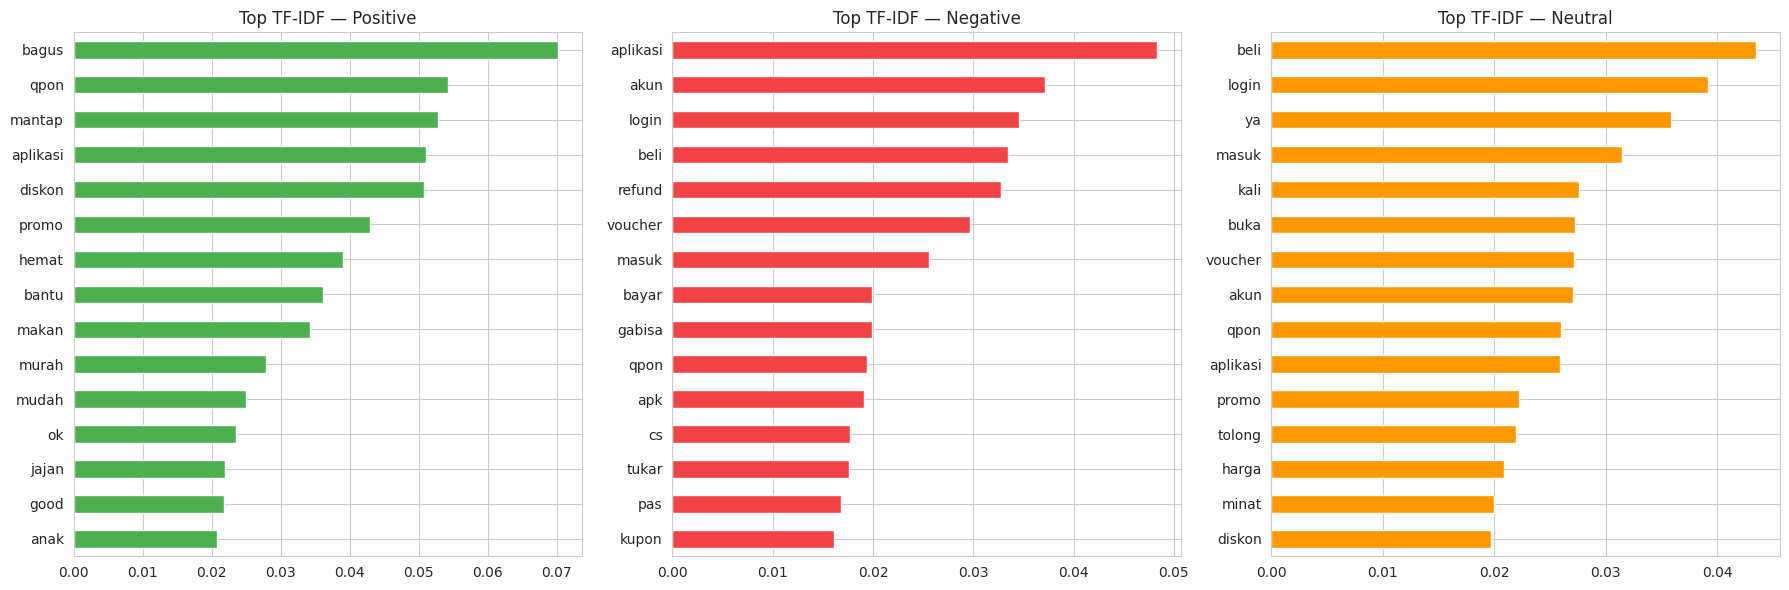

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sent, color in zip(axes, ['positive', 'negative', 'neutral'],
                            ['#4CAF50', '#F44346', '#FF9800']):
    mask = df['sentiment'] == sent
    # Convert the pandas Series mask to a NumPy array for sparse matrix indexing
    mean_tfidf = pd.Series(X_tfidf[mask.values].mean(axis=0).A1, index=vocab)
    top = mean_tfidf.sort_values(ascending=False).head(15)
    top.plot.barh(ax=ax, color=color)
    ax.set_title(f'Top TF-IDF — {sent.title()}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 4. BoW vs TF-IDF Comparison

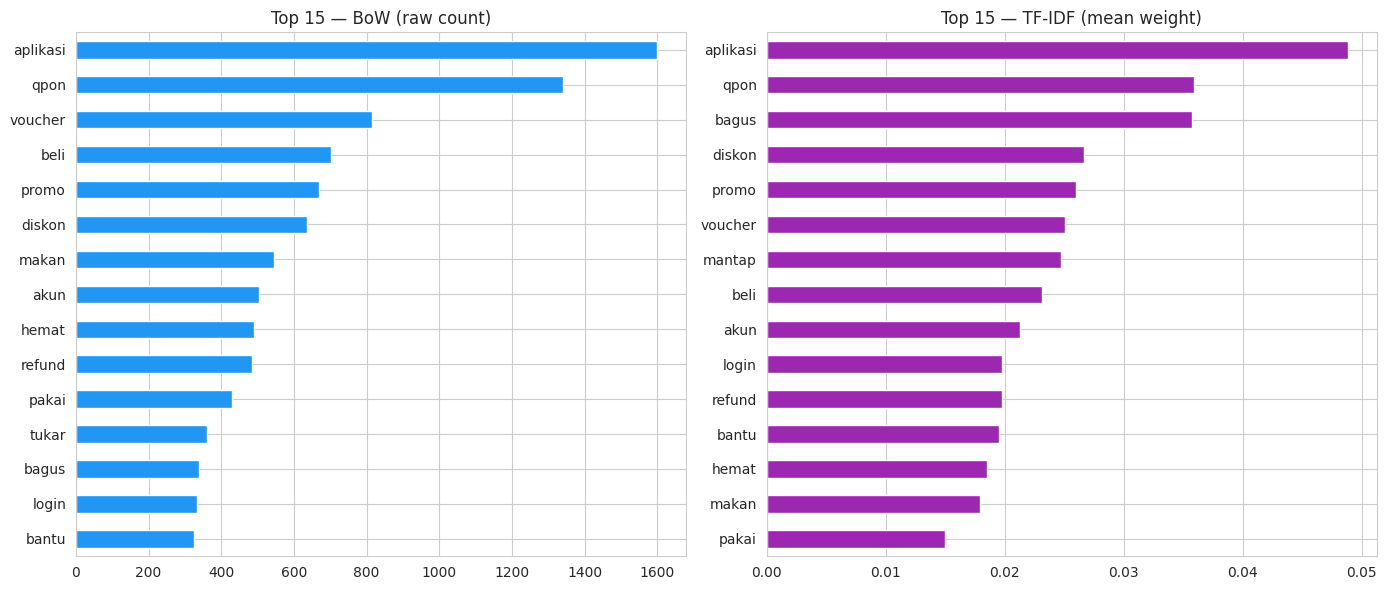

BoW favors high-frequency words regardless of document spread.
TF-IDF downweights common terms and surfaces more distinctive vocabulary.


In [17]:
# same vocab for fair comparison
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['processed'])

bow_top = pd.Series(X_bow.toarray().sum(axis=0), index=bow.get_feature_names_out()).sort_values(ascending=False).head(15)
tfidf_top = pd.Series(X_tfidf.toarray().mean(axis=0), index=vocab).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bow_top.plot.barh(ax=axes[0], color='#2196F3')
axes[0].set_title('Top 15 — BoW (raw count)')
axes[0].invert_yaxis()

tfidf_top.plot.barh(ax=axes[1], color='#9C27B0')
axes[1].set_title('Top 15 — TF-IDF (mean weight)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('BoW favors high-frequency words regardless of document spread.')
print('TF-IDF downweights common terms and surfaces more distinctive vocabulary.')

---
## 5. Simple Classifier Benchmark
Quick test: how well can we predict sentiment from TF-IDF features?

In [18]:
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 3,727  Test: 932


In [19]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print('Naive Bayes:')
print(classification_report(y_test, nb_pred))

Naive Bayes:
              precision    recall  f1-score   support

    negative       0.83      0.95      0.89       463
     neutral       0.00      0.00      0.00        34
    positive       0.93      0.86      0.90       435

    accuracy                           0.88       932
   macro avg       0.59      0.60      0.59       932
weighted avg       0.85      0.88      0.86       932



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print('Logistic Regression:')
print(classification_report(y_test, lr_pred))

Logistic Regression:
              precision    recall  f1-score   support

    negative       0.82      0.96      0.89       463
     neutral       0.00      0.00      0.00        34
    positive       0.94      0.84      0.89       435

    accuracy                           0.87       932
   macro avg       0.59      0.60      0.59       932
weighted avg       0.85      0.87      0.86       932



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


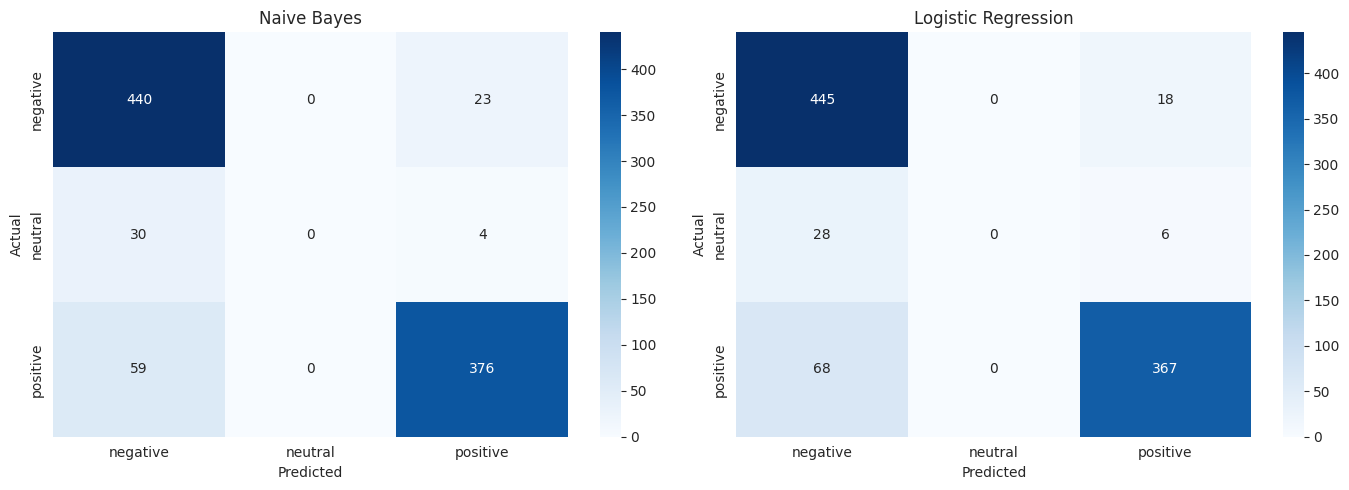

In [21]:
# confusion matrix for the better model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(axes, [nb_pred, lr_pred], ['Naive Bayes', 'Logistic Regression']):
    labels = sorted(y.unique())
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
## Summary

**TF-IDF** surfaces more distinctive terms per sentiment compared to raw BoW counts — common words get downweighted, and category-specific vocabulary rises to the top.

**BoW vs TF-IDF:** BoW top terms are dominated by universally frequent words. TF-IDF better differentiates what makes positive vs negative reviews unique.

**Classifier benchmark:** Both Naive Bayes and Logistic Regression tested on 80/20 split with TF-IDF features. Results show how well text features alone can predict sentiment.